# Анализ алгоритмов (Для взвешенного по спросу ИП-5)

In [3]:
import time
import random

import geopandas as gpd
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from genesis.metrics import *
from genesis.states import FirstArrivalUnitState
from genesis.utils import Progressbar, timing
from genesis.swiss_knife import CMAP_GrGldRd
from genesis.best_points import BestNodeHillClimbing, BestNodesFull, BestNodeMonkey, BestNodesHalfDiameter, BestNodeBee, NodeMetric
from genesis.mclp import BestNodesSA
from genesis.utils import TimeCheckPoint
from genesis.point_selectors import RandomNodesSelector
from genesis.stop_cases import NSameStopCase
from fire_units.metrics import Demand
from fire_units.mclp import BestNodesGAKopt
from genesis.mclp import BestNodesGA, BestNodesKoptG
from fire_units.best_points import BestNodeHillClimbingHD
from fire_units.metrics import CoverIndexBuilding
from genesis.stop_cases import MoreEqualStopCase

# Загрузка исходных данных и разбиение по районам

In [19]:
map_path = 'D:/QGIS/_Красноярск ДИССЕРТАЦИЯ'
# map_path = 'G:/QGIS/_Красноярск ДИССЕРТАЦИЯ'

# ГДС
G = ox.load_graphml(map_path+"/fire_data/rng.ml")
print(G.number_of_nodes(), G.number_of_edges())

# районы
districts = gpd.read_file(map_path+"/data/districts.gpkg", layer='Районы')
districts = districts.set_index(districts['name'])
# districts.plot(column='name', legend=True)
print('Районы Красноярска:', list(districts.index))

# здания
buildings = gpd.read_file(map_path+"/data/bld.gpkg", layer='здания')
buildings = buildings[['osmid', 'building', 'kfpo_spros', 'geometry']]   # 'name', 'amenity', 
buildings = buildings.set_index('osmid')
print('Всего зданий в Красноярске:', len(buildings))

31293 77344
Районы Красноярска: ['Железнодорожный район', 'Кировский район', 'Ленинский район', 'Октябрьский район', 'Свердловский район', 'Советский район', 'Центральный район']
Всего зданий в Красноярске: 58094


Установка скоростей следования для ГДС

In [20]:
from graphs.speeds import kmh_to_mm, set_graph_travel_times

speeds = [53, 40, 28.1, 17.3, 5.4]
speeds = [kmh_to_mm(s) for s in speeds]

set_graph_travel_times(G, speeds)

d:\Git\genesis\work\genesis\graphs\speeds.py:98: UserWarning: Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. Рекомендуется устанавливать время следования для неупрощенного графа и только после этого упрощать
  warnings.warn("Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. " + \


Приведение к единой системе координат

In [6]:
print('Проверка СК:', end=' ')
if not G.graph['crs'] == districts.crs == buildings.crs:
    raise ValueError('CRS G, districts и buildings различны!')
else:
    print('CRS совпадают.')

Проверка СК: CRS совпадают.


In [21]:
G = ox.project_graph(G)
districts = ox.projection.project_gdf(districts)
buildings = ox.projection.project_gdf(buildings)

print('Проверка СК:', end=' ')
if not G.graph['crs'] == districts.crs == buildings.crs:
    raise ValueError('CRS G, districts и buildings различны!')
else:
    print('CRS совпадают.')

Проверка СК: CRS совпадают.


Дополнение зданий сведениями о ближайших узлах ГДС

In [22]:
g_nodes = ox.graph_to_gdfs(G, edges=False)
buildings = buildings.sjoin_nearest(g_nodes[['geometry']], max_distance=100)
buildings.rename(columns={'osmid_right': 'node'}, inplace=True)
buildings.head(2)

,building,kfpo_spros,geometry,node
osmid_left,,,,
31124557,ЖД Вокзал,0.004263,"POLYGON ((489382.996 6206660.037, 489362.583 6...",7575322143
31794319,Производственное здание,0.001053,"POLYGON ((498128.502 6206447.698, 498114.903 6...",7062915254


Разбор графа и зданий на наборы для районов

In [33]:
scopes = {}
for i, district in districts.iterrows():
    poly = district['geometry']
    print(f'{i:<27}: ', end='')

    # Граф
    g_nodes_in = g_nodes.loc[g_nodes.intersects(poly.buffer(1000))]
    g = nx.subgraph(G, g_nodes_in.index)

    # оставляем только больший сильносвязный компонент:
    g = nx.subgraph(g, max(nx.strongly_connected_components(g), key=len))

    # Граф в пределах границ районов
    g_nodes_in2 = g_nodes.loc[g_nodes.intersects(poly)]
    g2 = nx.subgraph(G, g_nodes_in2.index)

    # оставляем только больший сильносвязный компонент:
    g2 = nx.subgraph(g, max(nx.strongly_connected_components(g2), key=len))
    print(f'{g.number_of_nodes()}/{g2.number_of_nodes()}',
          f'{g.number_of_edges()}/{g2.number_of_edges()}',
          end='\t')

    # Здания
    b = buildings.loc[buildings.intersects(poly)]
    b = b.sjoin_nearest(g_nodes_in2[['geometry']], max_distance=100)
    b.rename(columns={'osmid_right': 'node'}, inplace=True)
    print(len(b))

    scopes[i] = [poly, g, b]

Железнодорожный район      : 3515/1824 8411/4409	2870
Кировский район            : 5100/1482 12939/3819	3317
Ленинский район            : 5953/4218 15022/10674	4806
Октябрьский район          : 7008/5233 17201/12752	11801
Свердловский район         : 5490/4368 13597/10839	15178
Советский район            : 9377/5664 22942/13856	8135
Центральный район          : 5641/2787 13763/6660	6445


In [24]:
# ДЛЯ ПЕЧАТИ КАРТЫ РАСКОММЕНТИРОВАТЬ!
def plot_g(name, g, b, poly, ax=None, nodes=None, t_max=5, **kwds):
    show_flag = ax is None
    if ax is None:
        fig, ax = plt.subplots(1,1, dpi=100, **kwds)
    ax.set_title(name)
    ax.set_axis_off()
    ax.set_facecolor('white')
    ox.plot_graph(g, node_size=0, edge_linewidth=0.2, ax=ax, show=False)
    b.plot(ax=ax)
    poly.plot(color='none', edgecolor='r', linewidth=1, ax=ax)
    if nodes is not None:
        times, nearest = FirstArrivalUnitState()(G, points=nodes)
        merged_df = pd.merge(b,
                    pd.concat([times, nearest], axis=1),
                    left_on=['node'],
                    right_index=True)
        merged_df['time_color'] = ['green' if t<=t_max else 'red' for t in merged_df['times']]
        merged_df.plot(ax=ax, column='nearest', cmap='plasma')

        g_nodes = ox.graph_to_gdfs(g, edges=False).loc[list(nodes.keys())]
        g_nodes.plot(ax=ax, color='r', markersize=50, marker='x', **kwds)

    if show_flag:
        plt.show()

# fig, axs = plt.subplots(3,3, tight_layout=True, figsize=(12,12), dpi=300)
# x,y = 0,0
# for district in districts.index:
#     print(f'{district} [{y,x}]: ', end='')
#     g = scopes[district][1]
#     b = scopes[district][2]
#     plot_g(district, g, b, districts.loc[[district]], axs[y,x])
#     x += 1
#     if x >= 3:
#         x = 0
#         y += 1
#     print('ok')

# ax=axs[2,1]
# ax.set_title('г. Красноярск')
# ax.set_axis_off()
# ax.set_facecolor('white')
# districts.plot(column='name', ax=ax, legend=True, legend_kwds={'fontsize': 6, 'markerscale':0.5})

# plt.delaxes(axs[2,2])

# fig.tight_layout()

# ТЕСТ, потом удалить!:
# # district = 'Железнодорожный район'
# # g = scopes[district][1]
# # b = scopes[district][2]
# # nodes = {list(g.nodes())[100]: '1', list(g.nodes())[200]: '2', list(g.nodes())[1000]: '3'}
# # fig, (ax1, ax2) = plt.subplots(1,2, dpi=100)
# # plot_g(district, g, b, districts.loc[[district]], ax=ax1)
# # plot_g(district, g, b, districts.loc[[district]], nodes=nodes, ax=ax2)

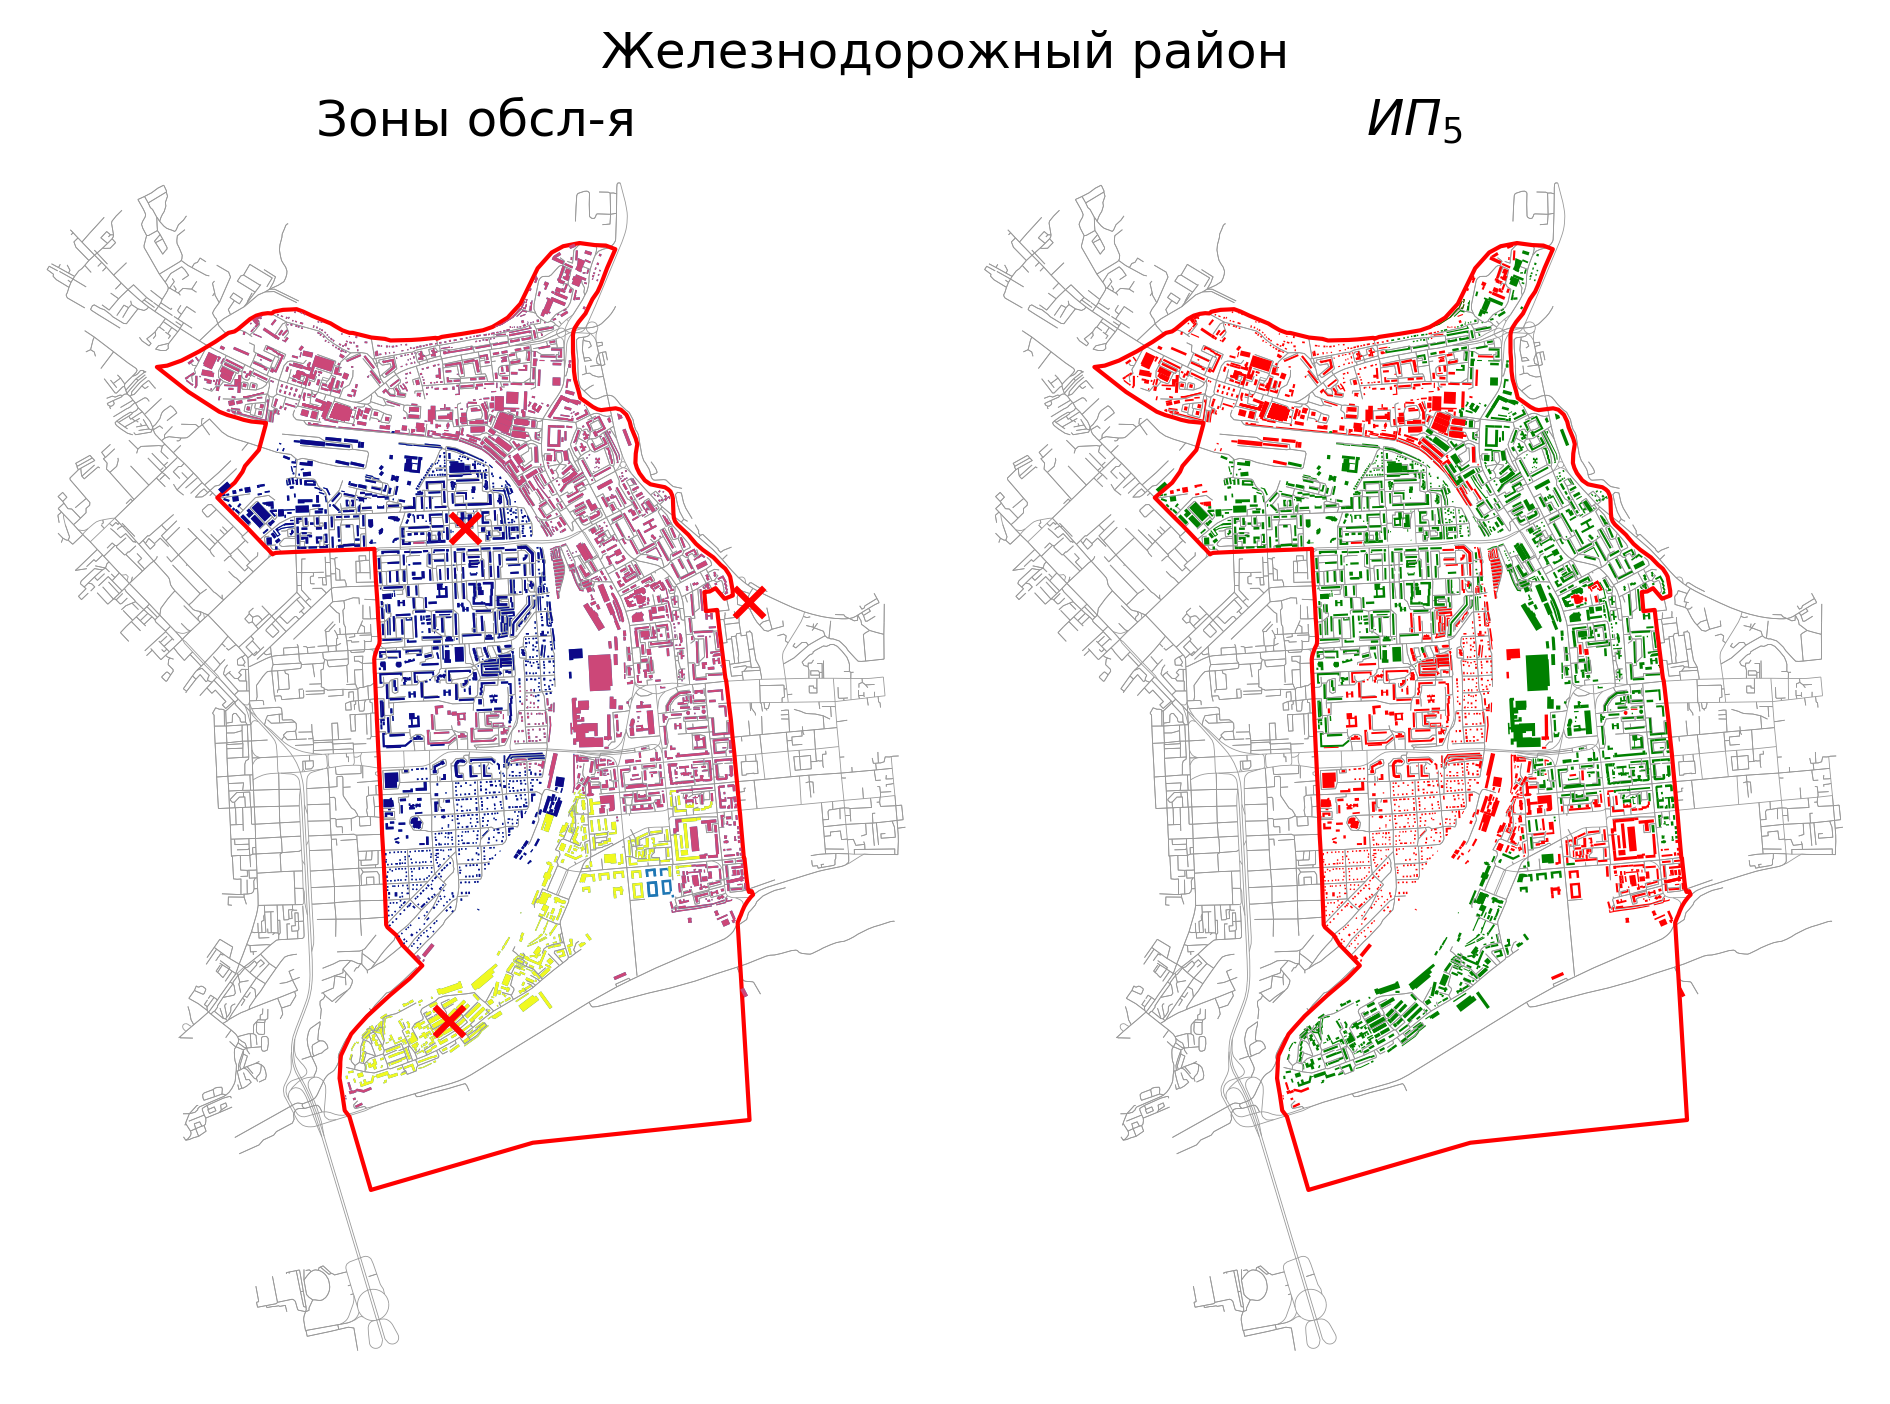

In [25]:
def plot_g2(name, g, b, poly, nodes, t_max=5, **kwds):
    
    fig, (ax, ax2) = plt.subplots(1,2, dpi=300, **kwds)

    ax.set_title('Зоны обсл-я')
    ax.set_axis_off()
    ax.set_facecolor('white')
    ox.plot_graph(g, node_size=0, edge_linewidth=0.2, ax=ax, show=False)
    b.plot(ax=ax)
    poly.plot(color='none', edgecolor='r', linewidth=1, ax=ax)



    ox.plot_graph(g, node_size=0, edge_linewidth=0.2, ax=ax2, show=False)
    times, nearest = FirstArrivalUnitState()(G, points=nodes)
    merged_df = pd.merge(b,
                pd.concat([times, nearest], axis=1),
                left_on=['node'],
                right_index=True)
    merged_df['time_color'] = ['green' if t<=t_max else 'red' for t in merged_df['times']]
    merged_df.plot(ax=ax, column='nearest', cmap='plasma')
    merged_df.plot(ax=ax2, color=merged_df['time_color'])
    poly.plot(color='none', edgecolor='r', linewidth=1, ax=ax2)

    g_nodes = ox.graph_to_gdfs(g, edges=False).loc[list(nodes.keys())]
    g_nodes.plot(ax=ax, color='r', markersize=50, marker='x', **kwds)
    
    ax2.set_title(f'$ИП_{t_max}$')
    ax2.set_axis_off()

    fig.suptitle(name)

    fig.tight_layout()
    plt.show()

# ТЕСТ, потом удалить!:
district = 'Железнодорожный район'
g = scopes[district][1]
b = scopes[district][2]
nodes = {list(g.nodes())[100]: '1', list(g.nodes())[200]: '2', list(g.nodes())[1000]: '3'}
plot_g2(district, g, b, districts.loc[[district]], nodes=nodes)

# Вычислительные эксперименты

## BLP

In [56]:
# Из кэша
tdfexisted = pd.read_csv('blp.csv')
tdfexisted = tdfexisted.set_index('Unnamed: 0')
tdfexisted

,Железнодорожный район время,Железнодорожный район точность,Железнодорожный район точность2,Железнодорожный район узел
Unnamed: 0,,,,
Full,717.25,100.0,100.0,345759063


In [91]:
# Из кэша
tdfexisted = pd.read_csv('blp.csv')
tdfexisted = tdfexisted.set_index('Unnamed: 0')


from fire_units.metrics import CoverIndexValue
from genesis.lscp import LSCP_ADD
from genesis.states import ArrivalTimeMatrixState, get_atm


def save_experiment_state():
    # Сохранение итогов в основные словари:
    main_times_list[district+' время'] = times_list
    main_accuracy_list[district+' точность'] = accuracy_list
    main_accuracy2_list[district+' точность2'] = accuracy2_list
    main_best_node_list[district+' узел'] = best_node_list
    # ------------------------------
    tdf = pd.DataFrame({**main_times_list, **main_accuracy_list, **main_accuracy2_list, **main_best_node_list})
    tdf.to_csv('blp.csv')


main_times_list = {}
main_accuracy_list = {}
main_accuracy2_list = {}
main_best_node_list = {}

for district, scope in scopes.items():
    print(' ')
    print('='*80)
    print(district)
    g = scopes[district][1]
    nodes = ox.graph_to_gdfs(g, edges=False)
    area_nodes = nodes.within(scopes[district][0])
    nodes_list=set(nodes[area_nodes].index)
    b = scopes[district][2]
    nodes_list_list = list(g.nodes())
    b = b.query(f'node in @nodes_list_list')
    print('Узлов', sum(area_nodes))
    print('Зданий', len(b))
    print('='*80)

    # функция метрики спроса
    metric_demand = CoverIndexValue(b, value_field='kfpo_spros', ip_val=5)

    # Списки результатов расчета
    times_list = {}
    accuracy_list = {}
    accuracy2_list = {}     # Для метрики по результату
    best_node_list = {}
    t = TimeCheckPoint()
    t2 = TimeCheckPoint()

    # Расчет полным перебором
    # ============================================================================
    print('\n', '# Расчет полным перебором')
    print('-'*80)
    try:
        accuracy_list['Full'] = tdfexisted.loc['Full'][district+' точность']
        accuracy2_list['Full'] = tdfexisted.loc['Full'][district+' точность2']
        times_list['Full'] = tdfexisted.loc['Full'][district+' время']
        best_node_list['Full'] = tdfexisted.loc['Full'][district+' узел']

        # Сохраняем эталонные значения
        etalon_node, etalon_time = best_node_list['Full'], times_list['Full']
        if np.isnan(etalon_time):
            raise ValueError('Значение не было вычислено!')
        etalon_node = int(float(etalon_node))
        etalon_metric = NodeMetric(FirstArrivalUnitState(), metric_demand)(g, etalon_node, area=area_nodes)
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        pb = Progressbar(sum(area_nodes), bins=40)
        full = BestNodesFull(FirstArrivalUnitState(), metric_demand, node_calc_end_function=pb)
        best_nodes, best_metric = full(env=g, area=area_nodes, nodes_list=nodes_list)
        time_spent = t()

        # Сохраняем результат вычисления
        times_list['Full'] = time_spent
        accuracy_list['Full'] = 100.0
        accuracy2_list['Full'] = 100.0
        best_node_list['Full'] = best_nodes
        save_experiment_state()

        # Сохраняем эталонные значения
        etalon_metric = best_metric
        etalon_node, etalon_time = best_node_list['Full'], times_list['Full']
    
    etalon_time = etalon_time if etalon_time < 600 else 600

    print(f'ЭТАЛОННЫЙ УЗЕЛ: {etalon_node}')
    print(f'ЭТАЛОННАЯ МЕТРИКА: {etalon_metric}')
    print(f'РАСЧЕТНОЕ ВРЕМЯ: {etalon_time}')

    # Расчет ADD  Жадное добавление
    # ============================================================================
    alg_name = 'ADD'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        bn_list = []
        t()
        matrix = get_atm(g, data=b, cutoff=5)
        lscp_add = LSCP_ADD(
            state_function = ArrivalTimeMatrixState(matrix),
            matrix = matrix,
            metric_function = metric_demand,
            after_mclp_function = lambda iteration, dynamic_nodes, best_metric, **kwargs: print(iteration, len(dynamic_nodes), best_metric),
            stop_case_function = lambda current_metric, dynamic_nodes, **kwargs: len(dynamic_nodes) >= 1,
            names_pattern = 'псч {}',
            ip_val = 5
        )

        best_node, best_metric = lscp_add()

        # Коррекция с учетом общего расчета состояния
        fau_state = FirstArrivalUnitState()
        times, _ = fau_state(env=g, points=best_node, area=area_nodes)
        best_metric = metric_demand(times, area=area_nodes)
        
        best_node = list(best_node.keys())[0]
        bn_list.append(best_node)
        print('\n', i, best_node, best_metric, t2(), end='\r') 
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = bn_list.count(etalon_node)
        times_list[alg_name] = round(time_spent, 1)
        accuracy_list[alg_name] = round(100*correct_results/len(bn_list),1)
        accuracy2_list[alg_name] = round(100 * best_metric / (etalon_metric), 1)
        best_node_list[alg_name] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list[alg_name]}', '|', accuracy2_list[alg_name])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list[alg_name]} сек')


    # Расчет HC
    # ============================================================================
    alg_name = 'HC'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        bnhc = BestNodeHillClimbing(FirstArrivalUnitState(), metric_demand)
        bn_list = []
        bn_metrics = []
        i=1
        t()
        while t(False) < etalon_time:
            t2()
            start_node = random.choice(list(nodes_list))
            best_node, best_metric = bnhc(env=g, area=area_nodes, start_point=start_node)
            bn_list.append(best_node)
            bn_metrics.append(best_metric)
            print('\n', i, best_node, best_metric, t2(), end='\r')
            i+=1
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = bn_list.count(etalon_node)
        times_list[alg_name] = round(time_spent/len(bn_list), 1)
        accuracy_list[alg_name] = round(100*correct_results/len(bn_list), 1)
        accuracy2_list[alg_name] = round(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)), 1)
        best_node_list[alg_name] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["HC"]}', '|', accuracy2_list['HC'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["HC"]} сек')

    # Расчет MSA
    # ============================================================================
    alg_name = 'MSA'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        class EventFunc:
            def __init__(self):
                pass
            def __call__(self, **kwargs):
                global_jump_number = kwargs['global_jump_number']
                local_jump_number = kwargs.get('local_jump_number', 0)
                print("Глобальный прыжок:", global_jump_number, ", Локальный прыжок:", local_jump_number, '  ', end='\r')

        bnmsa = BestNodeMonkey(FirstArrivalUnitState(), metric_demand, 
                                    global_jumps_count=2,
                                    local_jumps_count=5,
                                    all_neighbors=True,
                                    after_global_jump_function=EventFunc(),
                                    after_local_jump_function=EventFunc(),
                                    )
        bn_list = []
        bn_metrics = []
        i=1
        t()
        while t(False) < etalon_time:
            t2()
            best_node, best_metric = bnmsa(env=g, area=area_nodes)
            bn_list.append(best_node)
            bn_metrics.append(best_metric)
            # print('\n', i, best_node, best_metric, t2(), end='\r')
            print(i, best_node, best_metric, t2())
            # print(etalon_metric)
            # print(bn_metrics)
            # print(100 * sum(bn_metrics))
            # print(etalon_metric * len(bn_metrics))
            # print(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)))
            # print(round(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)), 1))
            i+=1
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = bn_list.count(etalon_node)
        times_list['MSA'] = round(time_spent/len(bn_list), 1)
        accuracy_list['MSA'] = round(100*correct_results/len(bn_list),1)
        accuracy2_list['MSA'] = round(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)), 1)
        best_node_list['MSA'] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["MSA"]}', '|', accuracy2_list['MSA'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["MSA"]} сек')

    # Расчет HC+BNHD
    # ============================================================================
    alg_name = 'HC+BNHD'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        bnhd = BestNodesHalfDiameter(FirstArrivalUnitState(), metric_demand)
        bnhc = BestNodeHillClimbing(FirstArrivalUnitState(), metric_demand)

        t()
        start_node, _ = bnhd(env=g, area=area_nodes)
        best_node, best_metric = bnhc(env=g, area=area_nodes, start_point=start_node)
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = best_metric/etalon_metric
        times_list['HC+BNHD'] = time_spent
        accuracy_list['HC+BNHD'] = round(100*correct_results,1)
        accuracy2_list['HC+BNHD'] = round(100*correct_results,1)
        best_node_list['HC+BNHD'] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["HC+BNHD"]}', '|', accuracy2_list['HC+BNHD'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["HC+BNHD"]} сек')


    # Расчет MSA+BNHD
    # ============================================================================
    alg_name = 'MSA+BNHD'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        bnhd = BestNodesHalfDiameter(FirstArrivalUnitState(), metric_demand)
        bnmsa = BestNodeMonkey(FirstArrivalUnitState(), metric_demand, 
                                global_jumps_count=2,
                                local_jumps_count=10,
                                all_neighbors=True,
                                local_jump_max_distance=1500,
                                after_global_jump_function=EventFunc(),
                                after_local_jump_function=EventFunc(),
                                )

        bn_list = []
        bn_metrics = []
        i=1
        t()
        while t(False) < etalon_time:
            t2()
            start_node, _ = bnhd(env=g, area=area_nodes)
            best_node, best_metric = bnmsa(env=g, area=area_nodes, start_point=start_node)
            bn_list.append(best_node)
            bn_metrics.append(best_metric)
            print('\n', i, best_node, best_metric, t2(), end='\r')
            i+=1
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = bn_list.count(etalon_node)
        times_list['MSA+BNHD'] = round(time_spent/len(bn_list), 1)
        accuracy_list['MSA+BNHD'] = round(100*correct_results/len(bn_list),1)
        accuracy2_list['MSA+BNHD'] = round(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)), 1)
        best_node_list['MSA+BNHD'] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["MSA+BNHD"]}', '|', accuracy2_list['MSA+BNHD'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["MSA+BNHD"]} сек')






    # Расчет ABC
    # ============================================================================
    alg_name = 'ABC'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        bnabc = BestNodeBee(FirstArrivalUnitState(),
                        metric_demand,
                        # scouts_count=150,
                        # best_scouts_count=3,
                        )
        bn_list = []
        bn_metrics = []
        i=1
        t()
        while t(False) < etalon_time:
            t2()
            best_node, best_metric = bnabc(env=g, area=area_nodes, nodes_list=nodes_list)
            bn_list.append(best_node)
            bn_metrics.append(best_metric)
            print('\n', i, best_node, best_metric, t2(), end='\r')
            i+=1
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = bn_list.count(etalon_node)
        times_list['ABC'] = round(time_spent/len(bn_list), 1)
        accuracy_list['ABC'] = round(100*correct_results/len(bn_list),1)
        accuracy2_list['ABC'] = round(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)), 1)
        best_node_list['ABC'] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["ABC"]}', '|', accuracy2_list['ABC'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["ABC"]} сек')

    # Расчет SHS
    # ============================================================================
    alg_name = 'SHS'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        bnabc = BestNodeBee(FirstArrivalUnitState(),
                        metric_demand,
                        scouts_count=10,
                        best_scouts_count=10,
                        )
        bn_list = []
        bn_metrics = []
        i=1
        t()
        while t(False) < etalon_time:
            t2()
            best_node, best_metric = bnabc(env=g, area=area_nodes, nodes_list=nodes_list)
            bn_list.append(best_node)
            bn_metrics.append(best_metric)
            print('\n', i, best_node, best_metric, t2(), end='\r')
            i+=1
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = bn_list.count(etalon_node)
        times_list['SHS'] = round(time_spent/len(bn_list), 1)
        accuracy_list['SHS'] = round(100*correct_results/len(bn_list),1)
        accuracy2_list['SHS'] = round(100 * sum(bn_metrics) / (etalon_metric * len(bn_metrics)), 1)
        best_node_list['SHS'] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["SHS"]}', '|', accuracy2_list['SHS'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["SHS"]} сек')

    # Расчет SA
    # ============================================================================
    alg_name = 'SA'
    print('\n', f'# Расчет {alg_name}')
    print('-'*80)
    try:
        accuracy_list[alg_name] = tdfexisted.loc[alg_name][district+' точность']
        accuracy2_list[alg_name] = tdfexisted.loc[alg_name][district+' точность2']
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        best_node_list[alg_name] = tdfexisted.loc[alg_name][district+' узел']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:

        def best_state_find_function(turn:int, T:float, best_metric:float, cur_metric:float, best_bot:dict):
            print(f'\nШаг: {turn} |', f'T={T} |', f'Лучшая метрика: {best_metric} |', f'Лучшее положение: {best_bot} |')
        def turn_end_function(turn:int, T:float, best_metric:float, cur_metric:float, best_bot:dict):
            print(f'Шаг: {turn} |', f'T={round(T,5)} |', 
                  f'Лучшая метрика: {best_metric} |',
                  f'Текущая метрика: {cur_metric} |',
                  f'Лучшее положение: {best_bot} |',
                  end='\r')        

        node_selector = RandomNodesSelector(nodes_list=nodes_list)
        stop_case = NSameStopCase(n=2000)
        mclpsa = BestNodesSA(FirstArrivalUnitState(),
                            metric_demand,
                            node_selector=node_selector,
                            end_temperature=0.0001,
                            turns= 10000,
                             turn_end_function=turn_end_function,
                            # best_state_find_function=best_state_find_function,
                            stop_case_function=stop_case
                            )

        t()
        # best_node, best_metric = mclpsa(env=g, area=area_nodes, start_node=start_node)
        print({list(g.nodes())[0]:'best'})
        best_node, best_metric = mclpsa(env=g, area=area_nodes, dynamic_nodes={list(g.nodes())[0]:'best'})
        best_node = list(best_node.keys())[0]
        time_spent = t()

        # Сохраняем результат вычисления
        correct_results = best_metric/etalon_metric
        times_list['SA'] = time_spent
        accuracy_list['SA'] = round(100*correct_results,1)
        accuracy2_list['SA'] = round(100*correct_results,1)
        best_node_list['SA'] = best_node
        save_experiment_state()
        print('\n')
    print(f'ТОЧНОСТЬ: {accuracy_list["SA"]}', '|', accuracy2_list['SA'])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list["SA"]} сек')

    # ======================================================================
    # Сохранение итогов в основные словари:
    save_experiment_state()   

 
Железнодорожный район
Узлов 1861
Зданий 2863

 # Расчет полным перебором
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
ЭТАЛОННЫЙ УЗЕЛ: 345759063
ЭТАЛОННАЯ МЕТРИКА: 74.03582972180617
РАСЧЕТНОЕ ВРЕМЯ: 600

 # Расчет ADD
--------------------------------------------------------------------------------
|########################################| 100.0%
0 1 73.95877183918948

 9 345759063 74.03582972180617 24.01

ТОЧНОСТЬ: 100.0 | 100.0
ВРЕМЯ ОДНОГО РАСЧЕТА: 23.8 сек

 # Расчет HC
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
ТОЧНОСТЬ: 7.5 | 81.4
ВРЕМЯ ОДНОГО РАСЧЕТА: 7.6 сек

 # Расчет MSA
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
ТОЧНОСТЬ: 71.4 | 95.7
ВРЕМЯ ОДНОГО РАСЧЕТА: 85.8 сек

 # Расчет HC+BNHD
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
ТОЧНОСТЬ: 72.1 | 72.1
ВРЕМЯ ОДНОГО РАСЧ

## MCLP

In [ ]:
# Из кэша
tdfexisted = pd.read_csv('mclp.csv')
tdfexisted = tdfexisted.set_index('Unnamed: 0')
# tdfexisted = tdfexisted.drop('GA+GNS')
tdfexisted

In [90]:

main_times_list = {}
main_metrics_list = {}

units_count = 3

for district, scope in scopes.items():
    print(' ')
    print('='*80)
    print(district)
    g = scopes[district][1]
    nodes = ox.graph_to_gdfs(g, edges=False)
    area_nodes = nodes.within(scopes[district][0])
    nodes_list=set(nodes[area_nodes].index)
    b = scopes[district][2]
    nodes_list_list = list(g.nodes())
    b = b.query(f'node in @nodes_list_list')
    start_state = {random.sample(list(nodes_list), k=1)[0]:f'псч {i}' for i in range(units_count)}
    print('Узлов', sum(area_nodes))
    print('Зданий', len(b))
    print('='*80)

    # функция метрики спроса
    metric_demand = CoverIndexValue(b, value_field='kfpo_spros', ip_val=5)

    # Списки результатов расчета
    times_list = {}
    metrics_list = {}


    # Расчет ADD
    # ============================================================================
    print('\n', '# ADD')
    print('-'*80)

    try:
        best_metric = tdfexisted.loc['ADD'][district+' точность']
        time_spent = tdfexisted.loc['ADD'][district+' время']
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        t = TimeCheckPoint()
        # t2 = TimeCheckPoint()

        # здесь сам расчет
        matrix = get_atm(g, data=b, cutoff=5)
        lscp_add = LSCP_ADD(
            state_function = ArrivalTimeMatrixState(matrix),
            matrix = matrix,
            metric_function = metric_demand,
            after_mclp_function = lambda iteration, dynamic_nodes, best_metric, **kwargs: print(iteration, len(dynamic_nodes), best_metric),
            stop_case_function = lambda current_metric, dynamic_nodes, **kwargs: len(dynamic_nodes) >= units_count,
            names_pattern = 'псч {}',
            ip_val = 5
        )

        best_node, best_metric = lscp_add()

        # Коррекция с учетом общего расчета состояния
        fau_state = FirstArrivalUnitState()
        times, _ = fau_state(env=g, points=best_node, area=area_nodes)
        best_metric = metric_demand(times, area=area_nodes)

        # завершающая стадия расчета
        time_spent = t()
        print('\n')
    print(f'ЛУЧШИЙ РЕЗУЛЬТАТ: {best_metric}')
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {time_spent} сек')

    # Сохраняем результат вычисления
    times_list['ADD'] = time_spent
    metrics_list['ADD'] = best_metric


    # Расчет SA
    # ============================================================================
    print('\n', '# SA')
    print('-'*80)

    try:
        best_metric = tdfexisted.loc['SA'][district+' точность']
        time_spent = tdfexisted.loc['SA'][district+' время']
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        t = TimeCheckPoint()
        # t2 = TimeCheckPoint()

        # здесь сам расчет
        def turn_end_function(turn:int, T:float, best_metric:float, cur_metric:float, best_bot:dict):
            print(f'Шаг: {turn} |', f'T={T} |', f'Лучшая метрика: {best_metric} |', f'Лучшее положение: {best_bot} |', ' '*10, end='\r')
        def best_state_find_function(turn:int, T:float, best_metric:float, cur_metric:float, best_bot:dict):
            print(f'\nШаг: {turn} |', f'T={T} |', f'Лучшая метрика: {best_metric} |', f'Лучшее положение: {best_bot} |')
        point_selector = RandomNodesSelector(nodes_list=nodes_list)
        stop_case = NSameStopCase(n=2000)
        mclpsa = BestNodesSA(FirstArrivalUnitState(),
                            metric_demand,
                            node_selector = point_selector,
                            end_temperature = 0.0001,
                            turns = 5000,
                            mutation_max_count = 2,
                            turn_end_function=turn_end_function,
                            # best_state_find_function = best_state_find_function,
                            stop_case_function = stop_case
                            )
        best_state, best_metric = mclpsa(env=g, area=area_nodes, dynamic_nodes=start_state)

        # завершающая стадия расчета
        time_spent = t()
        print('\n')
    print(f'ЛУЧШИЙ РЕЗУЛЬТАТ: {best_metric}')
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {time_spent} сек')

    # Сохраняем результат вычисления
    times_list['SA'] = time_spent
    metrics_list['SA'] = best_metric


    # Расчет GA
    # ============================================================================
    print('\n', '# GA')
    print('-'*80)
    try:
        best_metric = tdfexisted.loc['GA'][district+' точность']
        time_spent = tdfexisted.loc['GA'][district+' время']
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        t = TimeCheckPoint()
        # t2 = TimeCheckPoint()

        # здесь сам расчет
        def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
            print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |', ' '*10, end='\r')
        point_selector = RandomNodesSelector(nodes_list=nodes_list)
        stop_case = NSameStopCase(n=20)
        mclpga = BestNodesGA(FirstArrivalUnitState(),
                        metric_demand,
                        node_selector = point_selector,
                        population_size=50,
                        elite_size=15,
                        epochs=30,
                        mutation_rate=0.5,
                        mutation_max_count=3,
                        epoch_end_function=epoch_end_function,
                        # stop_case_function = stop_case
                        )
        optimal_nodes, best_metric = mclpga(env=g, 
                                    dynamic_nodes=start_state,
                                    area=area_nodes,
                                    )

        # завершающая стадия расчета
        time_spent = t()
        print('\n')
    print(f'ЛУЧШИЙ РЕЗУЛЬТАТ: {best_metric}')
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {time_spent} сек')

    # Сохраняем результат вычисления
    times_list['GA'] = time_spent
    metrics_list['GA'] = best_metric


    # Расчет GNS
    # ============================================================================
    print('\n', '# GNS')
    print('-'*80)
    try:
        best_metric = tdfexisted.loc['GNS'][district+' точность']
        time_spent = tdfexisted.loc['GNS'][district+' время']
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        t = TimeCheckPoint()
        # t2 = TimeCheckPoint()

        # здесь сам расчет
        def iter_func(i, best_metric, **kwds):
            print(i, ':', best_metric, end='\r')
        bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                        metric_function=metric_demand,
                        )
        mclpgns = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                        metric_function=metric_demand,
                        best_point_function=bnhc,
                        iterations=5,
                        iter_calc_end_function=iter_func,
                        )
        optimal_nodes, best_metric = mclpgns(env=g,
                            dynamic_nodes=start_state,
                            area=area_nodes,
                            )

        # завершающая стадия расчета
        time_spent = t()
        print('\n')
    print(f'ЛУЧШИЙ РЕЗУЛЬТАТ: {best_metric}')
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {time_spent} сек')

    # Сохраняем результат вычисления
    times_list['GNS'] = time_spent
    metrics_list['GNS'] = best_metric




    # Расчет GNS+BNHD
    # ============================================================================
    alg_name = 'GNS+BNHD'
    print('\n', f'# {alg_name}')
    print('-'*80)
    try:
        best_metric = tdfexisted.loc[alg_name][district+' точность']
        time_spent = tdfexisted.loc[alg_name][district+' время']
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        t = TimeCheckPoint()
        # t2 = TimeCheckPoint()

        # здесь сам расчет
        def iter_func(i, best_metric, **kwds):
            print(i, ':', best_metric, end='\r')
        bnhc = BestNodeHillClimbingHD(state_function=FirstArrivalUnitState(),
                        metric_function=metric_demand,
                        )
        mclpgns = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                        metric_function=metric_demand,
                        best_point_function=bnhc,
                        iterations=5,
                        iter_calc_end_function=iter_func,
                        )
        optimal_nodes, best_metric = mclpgns(env=g,
                            dynamic_nodes=start_state,
                            area=area_nodes,
                            )

        # завершающая стадия расчета
        time_spent = t()
        print('\n')
    print(f'ЛУЧШИЙ РЕЗУЛЬТАТ: {best_metric}')
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {time_spent} сек')

    # Сохраняем результат вычисления
    times_list[alg_name] = time_spent
    metrics_list[alg_name] = best_metric


    # Расчет GA+GNS
    # ============================================================================
    print('\n', '# GA+GNS')
    print('-'*80)
    try:
        best_metric = tdfexisted.loc['GA+GNS'][district+' точность']
        time_spent = tdfexisted.loc['GA+GNS'][district+' время']
        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        t = TimeCheckPoint()
        # t2 = TimeCheckPoint()

        # здесь сам расчет
        def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
            print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |', ' '*10, end='\r')
        def iter_calc_end_function(i, best_metric, **kwargs):
            print(f'Итерация: {i} |', f'Лучшая метрика: {best_metric} |', ' '*10)  #, end='\r')
        # optimal_nodes, best_metric = mclpga(env=g, 
        #                               dynamic_nodes=start_state,
        #                               area=area_nodes,
        #                               )
        # optimal_nodes, best_metric = mclpgns(env=g,
        #                     dynamic_nodes=optimal_nodes,
        #                     area=area_nodes,
        #                     )
        bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                    metric_function=metric_demand,                      
                        )
        kopt = BestNodesKoptG(FirstArrivalUnitState(),
                            metric_function=metric_demand,
                            best_point_function=bnhc,
                            iterations=3,
                            iter_calc_end_function=iter_calc_end_function,
                            )
        point_selector = RandomNodesSelector(nodes_list=nodes_list)
        stop_case = NSameStopCase(n=20)
        mclp = timing(BestNodesGAKopt(FirstArrivalUnitState(),
                            metric_function=metric_demand,
                            kopt_function = kopt,
                            node_selector = point_selector,
                            population_size=50,
                            elite_size = 15,
                            epochs = 30,
                            mutation_rate = 0.5,
                            mutation_max_count=3,
                            epoch_end_function = epoch_end_function,
                            #    stop_case_function=stop_case,
        ))

        # Собственно применения построенного алгоритма
        optimal_nodes, best_metric = mclp(env=g,
                                    #   static_nodes=existed_units, 
                                    dynamic_nodes=start_state,
                                    area=area_nodes,
                                    )

        # завершающая стадия расчета
        time_spent = t()
        print('\n')
    print(f'ЛУЧШИЙ РЕЗУЛЬТАТ: {best_metric}')
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {time_spent} сек')

    # Сохраняем результат вычисления
    times_list['GA+GNS'] = time_spent
    metrics_list['GA+GNS'] = best_metric




    # Сохранение итогов в основные словари:
    main_times_list[district+' время'] = times_list
    main_metrics_list[district+' точность'] = metrics_list
    
    # Промежуточное сохранение в DataFrame с объединением main_times_list и main_metrics_list
    # ------------------------------
    tdf = pd.DataFrame({**main_times_list, **main_metrics_list})
    tdf.to_csv('mclp.csv')
    # tdf.to_csv(f'mclp {district}.csv')



 
Железнодорожный район
Узлов 1861
Зданий 2863

 # ADD
--------------------------------------------------------------------------------
|########################################| 100.0%
0 1 73.95877183918948
1 2 86.66485045831472
2 3 92.55301780993842


ЛУЧШИЙ РЕЗУЛЬТАТ: 92.63178293466737
ВРЕМЯ ОДНОГО РАСЧЕТА: 26.09 сек

 # SA
--------------------------------------------------------------------------------
Шаг: 4999 | T=0.0002 | Лучшая метрика: 94.94882006309588 | Лучшее положение: {5579223497: 'псч 2', 1380534834: 'псч 0', 449954012: 'псч 1'} |           1'} |            

ЛУЧШИЙ РЕЗУЛЬТАТ: 94.94882006309588
ВРЕМЯ ОДНОГО РАСЧЕТА: 913.32 сек

 # GA
--------------------------------------------------------------------------------
Эпоха: 29 | Лучшая метрика: 92.44279917515705 | Текущая метрика: 92.44279917515705 |           

ЛУЧШИЙ РЕЗУЛЬТАТ: 92.44279917515705
ВРЕМЯ ОДНОГО РАСЧЕТА: 280.39 сек

 # GNS
--------------------------------------------------------------------------------
4 : 83.

In [77]:
# Сохранение итогов в основные словари:
main_times_list[district+' время'] = times_list
main_metrics_list[district+' точность'] = metrics_list

# Промежуточное сохранение в DataFrame с объединением main_times_list и main_metrics_list
# ------------------------------
tdf = pd.DataFrame({**main_times_list, **main_metrics_list})
tdf.to_csv('mclp.csv')
# tdf.to_csv(f'mclp {district}.csv')

In [ ]:
tdfexisted = pd.read_csv('mclp.csv')
tdfexisted = tdfexisted.set_index('Unnamed: 0')
tdfexisted = tdfexisted.drop('GA+GNS')
tdfexisted

## LSCP

In [10]:
# Из кэша
tdfexisted = pd.concat([pd.read_csv('lscp copy.csv'), pd.read_csv('lscp copy 2.csv')], axis=1)
tdfexisted = tdfexisted.set_index('Unnamed: 0')
# tdfexisted = tdfexisted.drop('Ленинский район время', axis=1)
# tdfexisted = tdfexisted.drop('Ленинский район метрика', axis=1)
# tdfexisted = tdfexisted.drop('Ленинский район подразделений', axis=1)
tdfexisted

,v1,Железнодорожный район время,Кировский район время,Железнодорожный район метрика,Кировский район метрика,Железнодорожный район подразделений,Кировский район подразделений,Ленинский район время,Октябрьский район время,Свердловский район время,Советский район время,Ленинский район метрика,Октябрьский район метрика,Свердловский район метрика,Советский район метрика,Ленинский район подразделений,Октябрьский район подразделений,Свердловский район подразделений,Советский район подразделений
Unnamed: 0,,,,,,,,,,,,,,,,,,,
GNS,GNS,193.30,96.71,94.092678,91.432069,4,4,395.98,2313.22,486.15,730.74,90.461216,90.006804,90.177804,90.01991,7,22,9,14.0
GA+GNS,GA+GNS,377.35,583.27,92.960736,90.850673,4,4,2792.15,9543.80,5187.00,NaN,90.167715,90.023814,90.574394,NaN,8,23,8,NaN


 
Железнодорожный район
Узлов 1861

 # Расчет GNS
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
МЕТРИКА: 94.0926777502653 | ПОДРАЗДЕЛЕНИЙ 4
ВРЕМЯ ОДНОГО РАСЧЕТА: 193.3 сек

 # Расчет GA+GNS
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
МЕТРИКА: 92.9607357622922 | ПОДРАЗДЕЛЕНИЙ 4
ВРЕМЯ ОДНОГО РАСЧЕТА: 377.35 сек
 
Кировский район
Узлов 2607

 # Расчет GNS
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
МЕТРИКА: 91.43206854345163 | ПОДРАЗДЕЛЕНИЙ 4
ВРЕМЯ ОДНОГО РАСЧЕТА: 96.71 сек

 # Расчет GA+GNS
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
МЕТРИКА: 90.85067319461444 | ПОДРАЗДЕЛЕНИЙ 4
ВРЕМЯ ОДНОГО РАСЧЕТА: 583.27 сек
 
Ленинский район
Узлов 4356

 # Расчет GNS
--------------------------------------------------------------------------------
ИМЕЕТСЯ В КЭШЕ!
МЕТРИКА: 90.46121593291404 | ПОДР

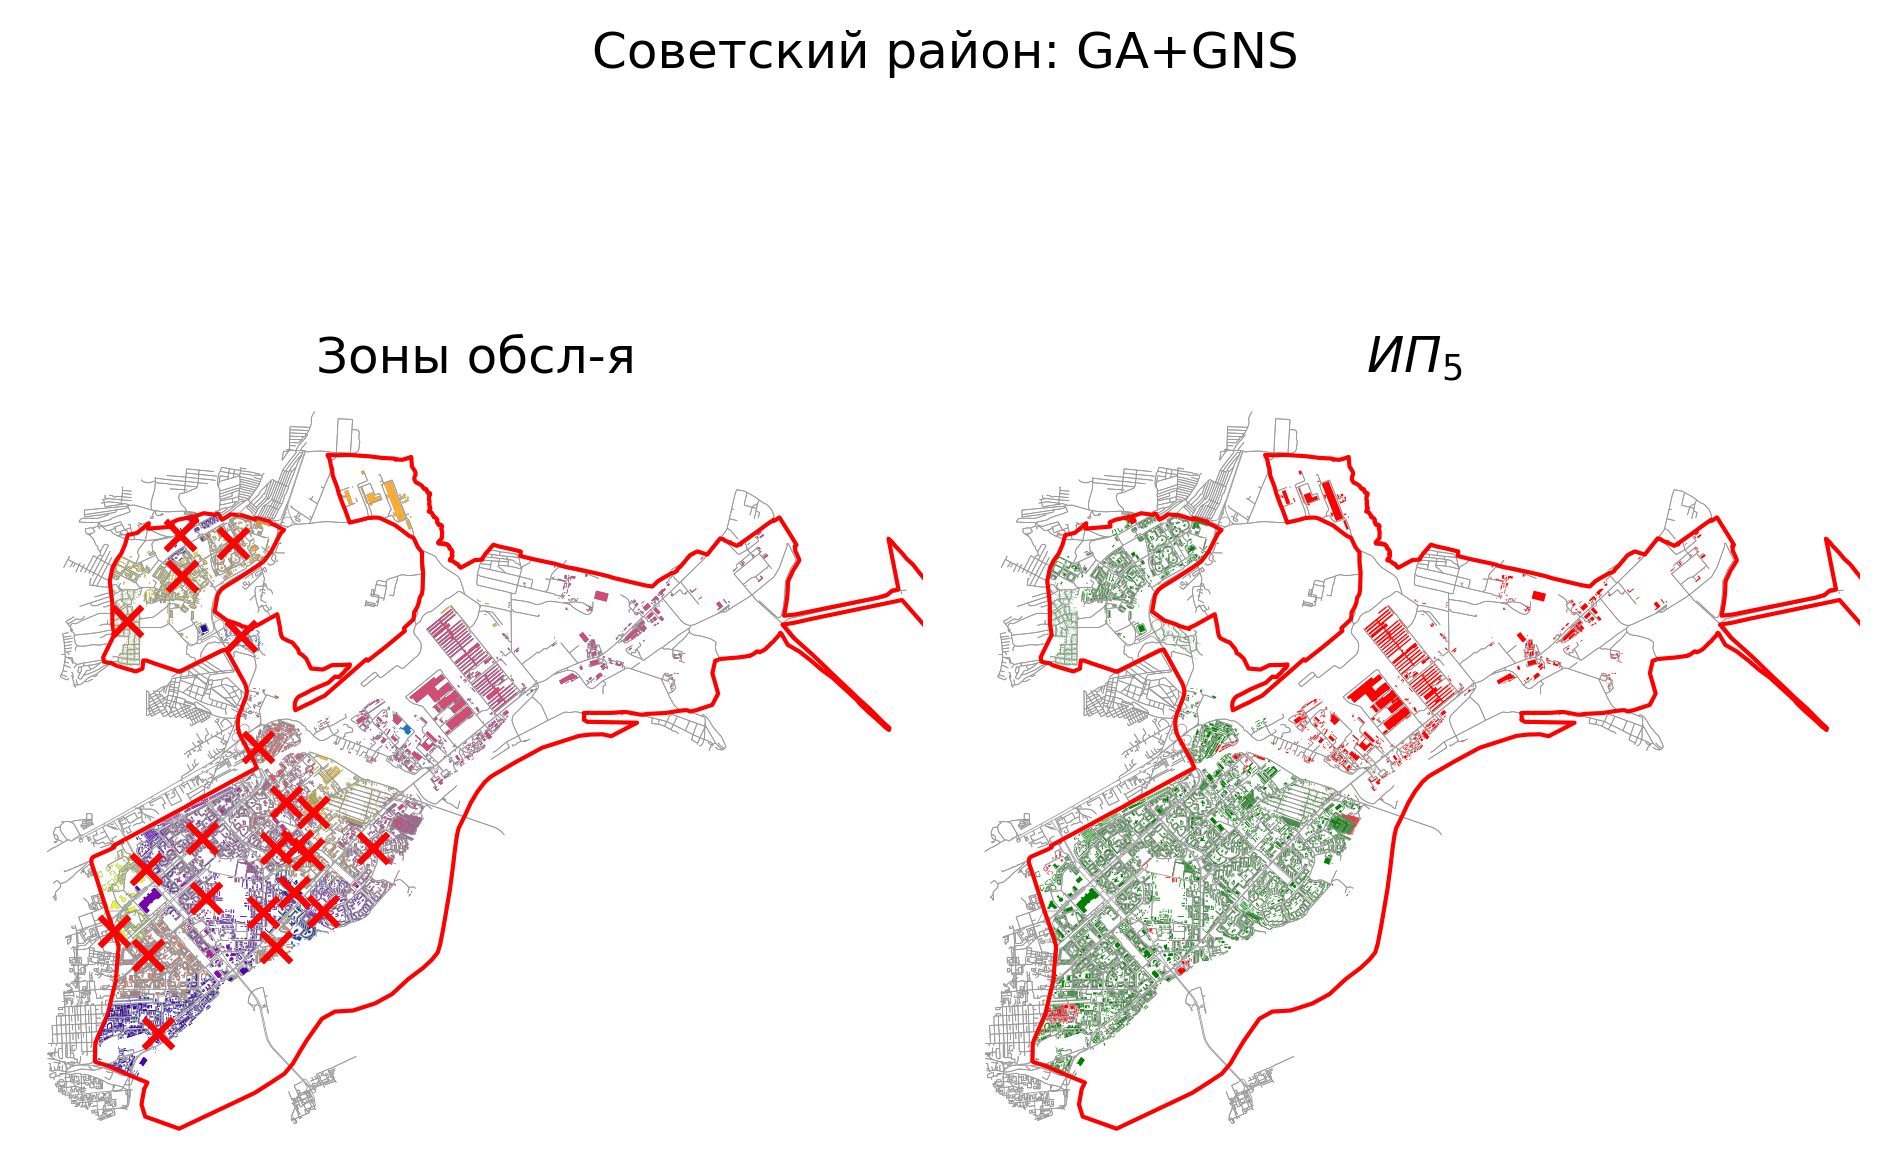



МЕТРИКА: 88.22797411647586 | ПОДРАЗДЕЛЕНИЙ 22
ВРЕМЯ ОДНОГО РАСЧЕТА: 10283.54 сек
 
Центральный район
Узлов 2802

 # Расчет GNS
--------------------------------------------------------------------------------
4 0.0008849180066097437
Итерация: 0 | Лучшая метрика: 0.0008849180066097437 | Подразделений: 2
Текущий ИП-5: 80.54157264363826 90
4 0.0009752021155988969
Итерация: 1 | Лучшая метрика: 0.0009752021155988969 | Подразделений: 3
Текущий ИП-5: 90.15795868772783 90
Текущий ИП-5: 90.15795868772783 90
Текущий ИП-5: 67.71393855233467 90
Текущий ИП-5: 67.71393855233467 90
 -> 1 Подразделений: 2 67.71393855233467 73.82
4 0.0008849180066097437
Итерация: 0 | Лучшая метрика: 0.0008849180066097437 | Подразделений: 2
Текущий ИП-5: 80.54157264363826 90
4 0.0009700109085377034
Итерация: 1 | Лучшая метрика: 0.0009700109085377034 | Подразделений: 3
Текущий ИП-5: 92.24093039402881 90
Текущий ИП-5: 92.24093039402881 90
Текущий ИП-5: 82.34681478909911 90
Текущий ИП-5: 82.34681478909911 90
 -> 2 Подразд

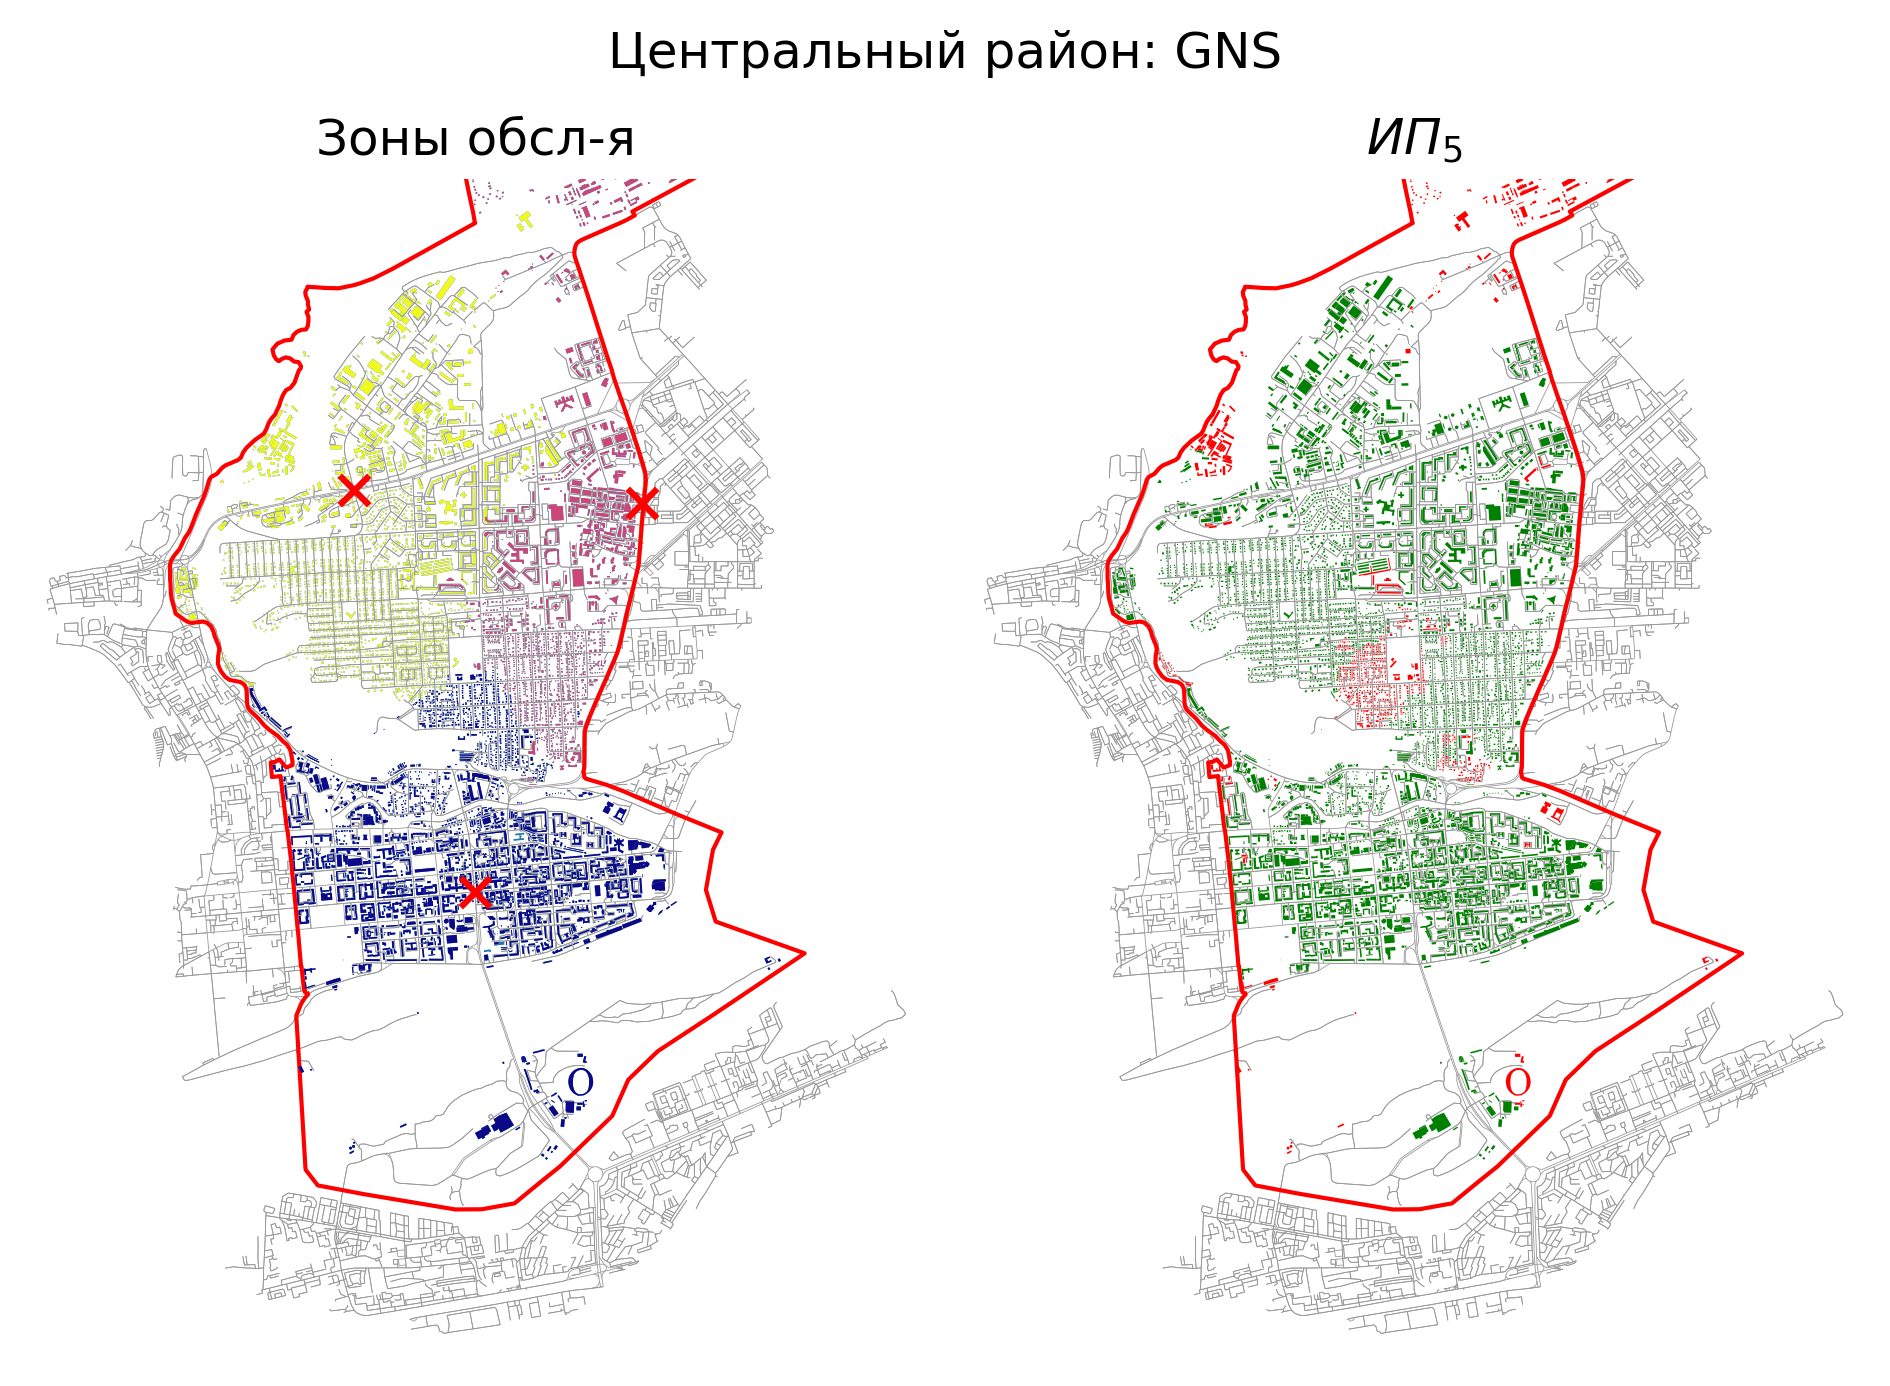



МЕТРИКА: 88.1964936642944 | ПОДРАЗДЕЛЕНИЙ 2
ВРЕМЯ ОДНОГО РАСЧЕТА: 73.82 сек

 # Расчет GA+GNS
--------------------------------------------------------------------------------
2 0.0008953575078063584ка: 0.0008725177491852054 | Текущая метрика: 0.0008725177491852054 |           
Итерация: 0 | Лучшая метрика: 0.0008953575078063584 | Подразделений: 2
Текущий ИП-5: 81.37476132615865 90
2 0.0009862806250962902ка: 0.0009475651735377326 | Текущая метрика: 0.0009475651735377326 |           
Итерация: 1 | Лучшая метрика: 0.0009862806250962902 | Подразделений: 3
Текущий ИП-5: 89.84551293178268 90
2 0.0010523912516540235ка: 0.0010239712131762007 | Текущая метрика: 0.0010239712131762007 |           
Итерация: 2 | Лучшая метрика: 0.0010523912516540235 | Подразделений: 4
Текущий ИП-5: 91.13001215066829 90
Текущий ИП-5: 91.13001215066829 90
Текущий ИП-5: 73.35532025689984 90
Текущий ИП-5: 73.35532025689984 90
Текущий ИП-5: 73.35532025689984 90
 -> 1 Подразделений: 3 73.35532025689984 791.76
2 0.0009

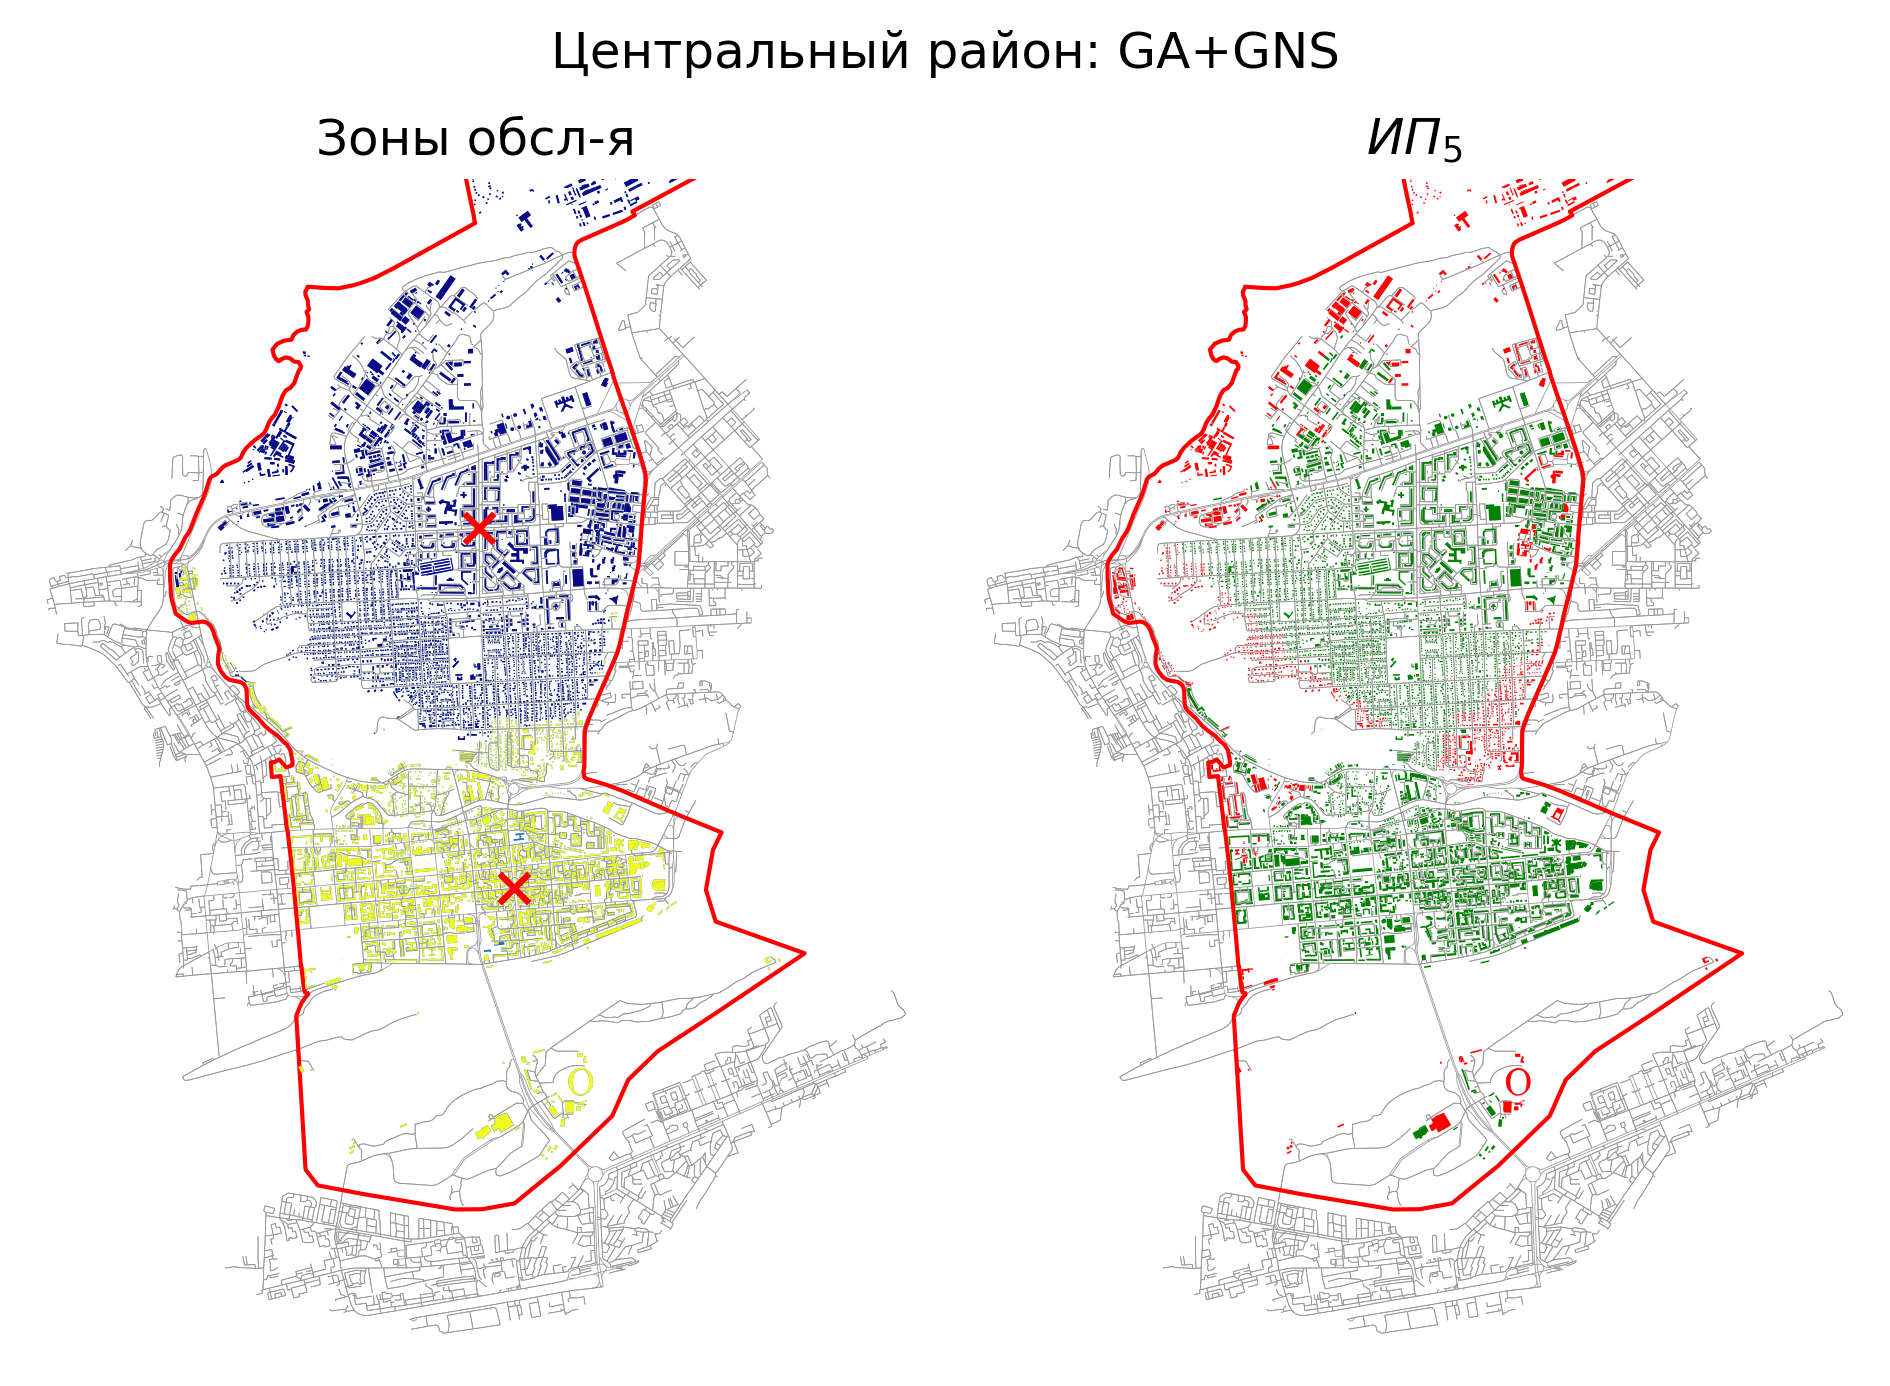



МЕТРИКА: 72.48741537927444 | ПОДРАЗДЕЛЕНИЙ 2
ВРЕМЯ ОДНОГО РАСЧЕТА: 558.43 сек


In [11]:
from diss.lscp import BestNodesGADiss, BestNodesSADiss
from genesis.lscp import LSCPCommon, drop_trash_points
from genesis.core import StateBase, StopCaseBase
from genesis.mclp import NodesMetric
from genesis.tools import list_dict_concat


runs_count = 3
units_count = 2
target_ip = 90
ip_val_main = 5

# Потом удалить!
def drop_trash_points(env,
                    state_function: StateBase,
                    metric_function: MetricBase,
                    stop_case_function: StopCaseBase,
                    dynamic_nodes,
                    static_nodes=None,
                    area=None,
                    ):
    '''
    Функция отброса мусорных размещений.
    В данном случае используется жадное удаление

    
    '''
    for node in dynamic_nodes:
        tmp = dynamic_nodes.copy()
        tmp.pop(node)

        if static_nodes is None:
            all_nodes = dynamic_nodes
        else:
            all_nodes = list_dict_concat(tmp, static_nodes)

        metric = NodesMetric(state_function, metric_function)(env, list(all_nodes.keys()), area=area)
        if stop_case_function(value=metric,
                            iteration=0,
                            best_metric=metric,
                            dynamic_nodes=dynamic_nodes,
                            static_nodes=static_nodes):
            dynamic_nodes = tmp
    
    if static_nodes is None:
        all_nodes = dynamic_nodes
    else:
        all_nodes = list_dict_concat(tmp, static_nodes)
    metric = NodesMetric(state_function, metric_function)(env, list(all_nodes.keys()), area=area)
    
    return dynamic_nodes, metric

def save_experiment_state_lscp():
    # Сохранение итогов в основные словари:
    main_times_list[district+' время'] = times_list
    main_metric_list[district+' метрика'] = metric_list
    main_units_count_list[district+' подразделений'] = units_count_list
    # ------------------------------
    tdf = pd.DataFrame({**main_times_list, **main_metric_list, **main_units_count_list})
    tdf.to_csv('lscp.csv')

# STOPCASE Здесь!
def stop_case_function(value,
                        iteration,
                        best_metric,
                        dynamic_nodes,
                        static_nodes,
                        target_ip=target_ip,
                        ip_val=ip_val_main):
    # times, _ = FirstArrivalUnitState()(env=g, points=dynamic_nodes, area=area_nodes)
    # ip = CoverIndexBuilding(buildings=b, ip_val=ip_val)(state=times, area=area_nodes)
    ip = NodesMetric(FirstArrivalUnitState(),
                     CoverIndexBuilding(buildings=b, ip_val=ip_val)
                     )(env=g, nodes=list(dynamic_nodes.keys()), area=area_nodes)
    print(f'Текущий ИП-{ip_val_main}:', ip, target_ip)
    if ip >= target_ip:
        return True
    return False

main_times_list = {}            # Время одной итерации
main_metric_list = {}           # Лучшая метрика полученная алгоритмом
main_units_count_list = {}      # Количество подразделений предложенное алгоритмом

for district, scope in scopes.items():
    print(' ')
    print('='*80)
    print(district)
    g = scopes[district][1]
    b = scopes[district][2]
    nodes = ox.graph_to_gdfs(g, edges=False)
    area_nodes = nodes.within(scopes[district][0])
    nodes_list=set(nodes[area_nodes].index)
    print('Узлов', sum(area_nodes))
    print('='*80)

    # функция метрики спроса
    metric_demand = Demand(b, buildings_demand_field='kfpo_spros')  #! учет влияния кол-ва подразделений зашит внутри GA и SA
    metric_ipbuild = CoverIndexBuilding(b, ip_val=ip_val_main)

    # Списки результатов расчета
    times_list = {}             # Время одной итерации
    metric_list = {}            # Лучшая метрика полученная алгоритмом
    units_count_list = {}       # Количество подразделений предложенное алгоритмом
    t = TimeCheckPoint()
    t2 = TimeCheckPoint()


    # Расчет GNS
    # ============================================================================
    alg_name = 'GNS'
    print('\n', '# Расчет {}'.format(alg_name))
    print('-'*80)
    try:
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        metric_list[alg_name] = tdfexisted.loc[alg_name][district+' метрика']
        units_count_list[alg_name] = tdfexisted.loc[alg_name][district+' подразделений']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')

        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        # здесь сам расчет
        def iter_func(i, best_metric, **kwds):
            print(i, best_metric, end='\r')
        def mclp_end_function(iteration, best_metric, dynamic_nodes, **kwargs):
            print(f'\nИтерация: {iteration} |', f'Лучшая метрика: {best_metric} |', f'Подразделений: {len(dynamic_nodes)}')
        # metric_ipbuild = CoverIndexBuilding(b, ip_val=ip_val_main)
        # stop_case = MoreEqualStopCase(target_ip)
        bnhc = BestNodeHillClimbingHD(state_function=FirstArrivalUnitState(),
                        metric_function=metric_demand,  #metric_ipbuild,  #metric_demand,
                        )
        mclpgns = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                        metric_function=metric_demand, #metric_ipbuild,
                        best_point_function=bnhc,
                        iterations=5,
                        iter_calc_end_function=iter_func,
                        # stop_case_function = stop_case
                        )
        point_selector = RandomNodesSelector(nodes_list=nodes_list)
        lscp = LSCPCommon(mclp_function = mclpgns,
                     point_selector = point_selector,
                    stop_case_function = stop_case_function,  # stop_case,
                    start_names_index = units_count+1,
                    names_pattern='псч {}',
                    after_mclp_function=mclp_end_function,
                    )
        

        # bn_times = []
        # bn_metrics = []
        # bn_units = []
        bn_times = None
        bn_metrics = None
        bn_units = None
        t()
        for i in range(runs_count):      # результат детерминирован, поэтому смысла в постоянных перерасчетах нет
            t2()

            start_state = {random.sample(list(nodes_list), k=1)[0]:f'псч {i+1}' for i in range(units_count)}
            optimal_nodes, best_metric = lscp(env=g,
                            dynamic_nodes=start_state,
                            area=area_nodes,
                            )
            optimal_nodes, best_metric = drop_trash_points(g,
                                                           FirstArrivalUnitState(),
                                                           metric_ipbuild,
                                                           stop_case_function,
                                                           optimal_nodes,
                                                           area=area_nodes)
            # bn_times.append(t2(False))
            # bn_metrics.append(best_metric)
            # bn_units.append(len(optimal_nodes))
            # print(i+1, 'Подразделений:', len(optimal_nodes), best_metric, t2(), end='\r')
            if bn_units is None:
                bn_times = t2(False)
                bn_metrics = best_metric
                bn_units = optimal_nodes
            else:
                # if metric_ipbuild.compare(bn_metrics, best_metric):
                if len(optimal_nodes) < len(bn_units):
                    bn_times = t2(False)
                    bn_metrics = best_metric
                    bn_units = optimal_nodes                    
            print(' ->', i+1, 'Подразделений:', len(optimal_nodes), best_metric, t2())
        time_spent = t()

        # Сохраняем результат вычисления
        # times_list[alg_name] = np.mean(bn_times)
        # metric_list[alg_name] = np.max(bn_metrics)
        # units_count_list[alg_name] = np.min(bn_units)
        times_list[alg_name] = bn_times
        metric_list[alg_name] = best_metric
        units_count_list[alg_name] = len(bn_units)
        plot_g2(f'{district}: {alg_name}', g, b, districts.loc[[district]], nodes=optimal_nodes, t_max=ip_val_main)

        save_experiment_state_lscp()
        print('\n')
    print(f'МЕТРИКА: {metric_list[alg_name]}', '| ПОДРАЗДЕЛЕНИЙ', units_count_list[alg_name])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list[alg_name]} сек')


    # Расчет GA+GNS
    # ============================================================================
    alg_name = 'GA+GNS'
    print('\n', '# Расчет {}'.format(alg_name))
    print('-'*80)
    try:
        times_list[alg_name] = tdfexisted.loc[alg_name][district+' время']
        metric_list[alg_name] = tdfexisted.loc[alg_name][district+' метрика']
        units_count_list[alg_name] = tdfexisted.loc[alg_name][district+' подразделений']
        if np.isnan(times_list[alg_name]):
            raise ValueError('Значение не было вычислено!')

        print(f'ИМЕЕТСЯ В КЭШЕ!')
    except:
        # здесь сам расчет
        def iter_func(i, best_metric, **kwds):
            print(i, best_metric, end='\r')
        def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
            print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |', ' '*10, end='\r')
        def mclp_end_function(iteration, best_metric, dynamic_nodes, **kwargs):
            print(f'\nИтерация: {iteration} |', f'Лучшая метрика: {best_metric} |', f'Подразделений: {len(dynamic_nodes)}')

        # metric_ipbuild = CoverIndexBuilding(b, ip_val=ip_val_main)
        bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                    metric_function=metric_demand,  #metric_ipbuild,  #metric_demand,                      
                        )
        kopt = BestNodesKoptG(FirstArrivalUnitState(),
                            metric_function=metric_demand, #metric_ipbuild,
                            best_point_function=bnhc,
                            iterations=3,
                            iter_calc_end_function=iter_func,
                            )
        point_selector = RandomNodesSelector(nodes_list=nodes_list)
        # metric_ipbuild = CoverIndexBuilding(b, ip_val=ip_val_main)
        mclp = BestNodesGAKopt(FirstArrivalUnitState(),
                            metric_function=metric_demand, #metric_ipbuild,
                            kopt_function = kopt,
                            node_selector = point_selector,
                            population_size=75,
                            elite_size = 15,
                            epochs = 10,
                            # epochs = 1,
                            mutation_rate = 0.5,
                            mutation_max_count=3,
                            epoch_end_function = epoch_end_function,
                            # stop_case_function=NSameStopCase(15),
        )
        lscp = LSCPCommon(mclp_function = mclp,
                     point_selector = point_selector,
                    stop_case_function = stop_case_function,  # MoreEqualStopCase(target_ip),
                    start_names_index = units_count+1,
                    names_pattern='псч {}',
                    after_mclp_function=mclp_end_function,
                    )
        
        start_state = {random.sample(list(nodes_list), k=1)[0]:f'псч {i}' for i in range(units_count)}

        bn_times = None
        bn_metrics = None
        bn_units = None
        t()
        for i in range(runs_count):
            t2()
            optimal_nodes, best_metric = lscp(env=g, 
                                    dynamic_nodes=start_state,
                                    area=area_nodes,
                                    )
            optimal_nodes, best_metric = drop_trash_points(g,
                                                           FirstArrivalUnitState(),
                                                           metric_ipbuild,
                                                           stop_case_function,
                                                           optimal_nodes,
                                                           area=area_nodes)
            # bn_times.append(t2(False))
            # bn_metrics.append(best_metric)
            # bn_units.append(len(optimal_nodes))
            if bn_units is None:
                bn_times = t2(False)
                bn_metrics = best_metric
                bn_units = optimal_nodes
            else:
                # if metric_ipbuild.compare(bn_metrics, best_metric):
                if len(optimal_nodes) < len(bn_units):
                    bn_times = t2(False)
                    bn_metrics = best_metric
                    bn_units = optimal_nodes                    
            print(' ->', i+1, 'Подразделений:', len(optimal_nodes), best_metric, t2())
        time_spent = t()

        # Сохраняем результат вычисления
        times_list[alg_name] = bn_times
        metric_list[alg_name] = best_metric
        units_count_list[alg_name] = len(bn_units)
        plot_g2(f'{district}: {alg_name}', g, b, districts.loc[[district]], nodes=bn_units, t_max=ip_val_main)

        save_experiment_state_lscp()
        print('\n')
    print(f'МЕТРИКА: {metric_list[alg_name]}', '| ПОДРАЗДЕЛЕНИЙ', units_count_list[alg_name])
    print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {times_list[alg_name]} сек')


In [12]:
bn_units

{1793025983: 'псч 0', 290662819: 'псч 3'}

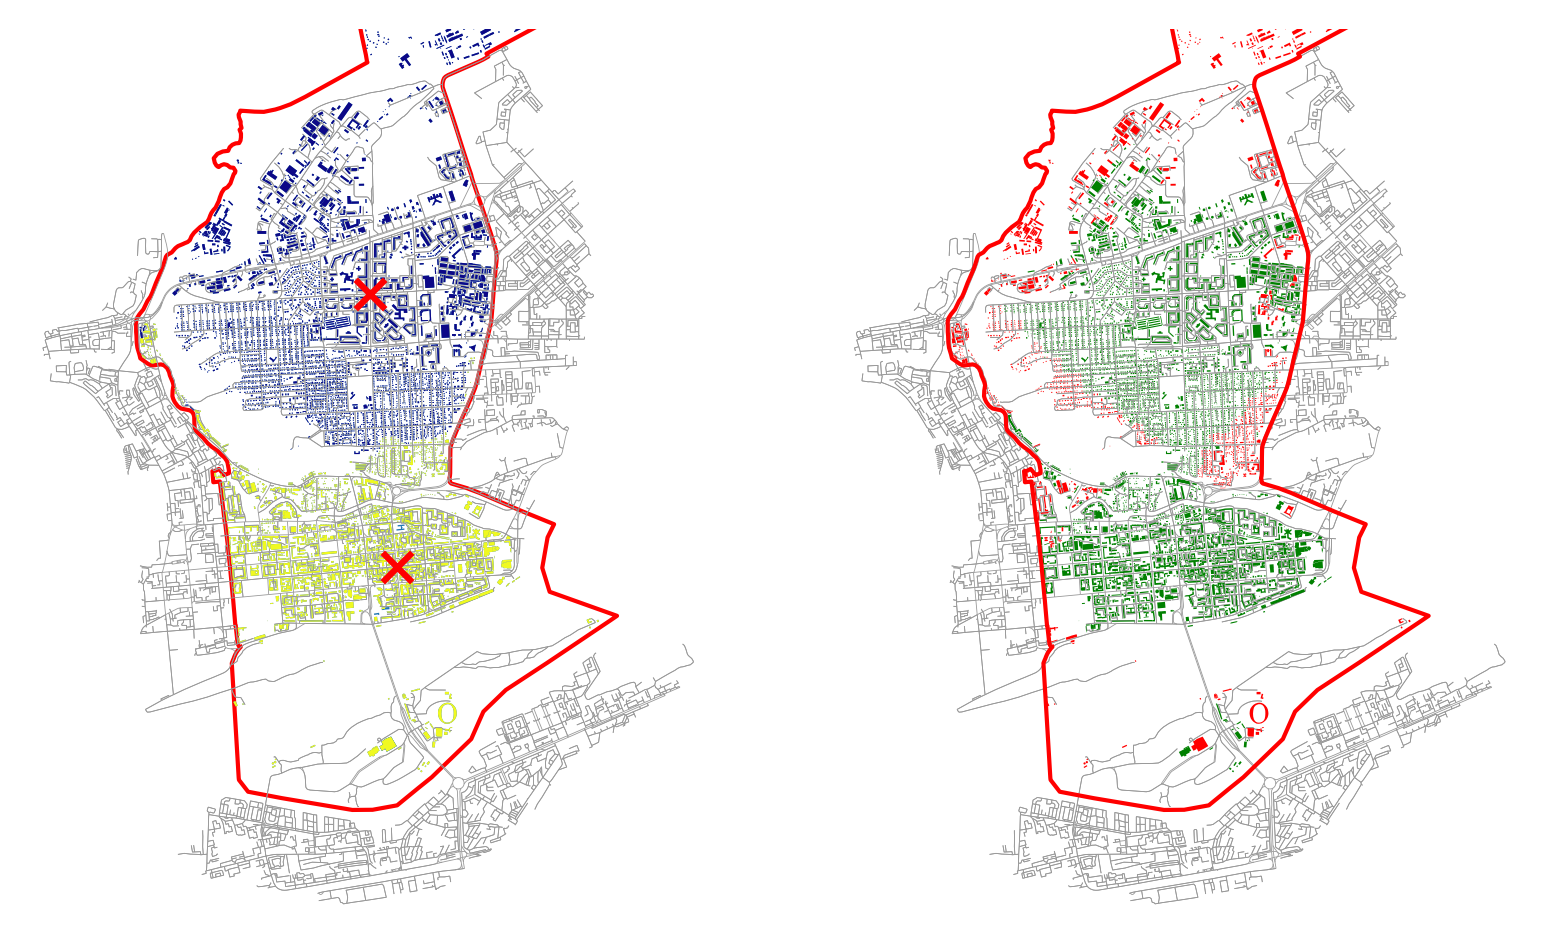

In [15]:
def plot_g3(name, g, b, poly, nodes, t_max=5, **kwds):
    
    fig, (ax, ax2) = plt.subplots(1,2, dpi=300, **kwds)

    # ax.set_title('Зоны обсл-я')
    ax.set_axis_off()
    ax.set_facecolor('white')
    poly.plot(color='none', edgecolor='r', linewidth=1, ax=ax)
    ox.plot_graph(g, node_size=0, edge_linewidth=0.2, ax=ax, show=False)
    b.plot(ax=ax)



    ox.plot_graph(g, node_size=0, edge_linewidth=0.2, ax=ax2, show=False)
    times, nearest = FirstArrivalUnitState()(G, points=nodes)
    merged_df = pd.merge(b,
                pd.concat([times, nearest], axis=1),
                left_on=['node'],
                right_index=True)
    merged_df['time_color'] = ['green' if t<=t_max else 'red' for t in merged_df['times']]
    merged_df.plot(ax=ax, column='nearest', cmap='plasma')
    merged_df.plot(ax=ax2, color=merged_df['time_color'])
    poly.plot(color='none', edgecolor='r', linewidth=1, ax=ax2)

    g_nodes = ox.graph_to_gdfs(g, edges=False).loc[list(nodes.keys())]
    g_nodes.plot(ax=ax, color='r', markersize=50, marker='x', **kwds)
    
    # ax2.set_title(f'$ИП_{t_max}$')
    ax2.set_axis_off()

    # fig.suptitle(name)

    # fig.tight_layout()
    plt.show()

# ТЕСТ, потом удалить!:
district = 'Центральный район'
g = scopes[district][1]
b = scopes[district][2]
# nodes = {list(g.nodes())[100]: '1', list(g.nodes())[200]: '2', list(g.nodes())[1000]: '3'}
plot_g3(district, g, b, districts.loc[[district]], nodes=bn_units)

# Черновики

#### Проверка корректности расчета по node

In [16]:
district = 'Железнодорожный район'
g = scopes[district][1]
b = scopes[district][2]
nodes = {list(g.nodes())[100]: '1', list(g.nodes())[200]: '2', list(g.nodes())[1000]: '3'}

times, nearest = FirstArrivalUnitState()(g, points=nodes)
print('times', len(times))

merged_df = pd.merge(b,
                    times,
                    left_on='node',
                    right_index=True)

merged_df

times 3515


,building,kfpo_spros,geometry,node,times
osmid,,,,,
31124557,ЖД Вокзал,0.004263,"POLYGON ((489382.996 6206660.037, 489362.583 6...",7575322143,4.510984
123922009,Административное здание,0.001086,"POLYGON ((489451.650 6206849.431, 489462.109 6...",7575322143,4.510984
300032899,ЖД Вокзал,0.004263,"POLYGON ((489403.875 6206815.113, 489422.384 6...",7575322143,4.510984
170845790,Коммерческое здание,0.003726,"POLYGON ((489484.648 6206825.766, 489478.261 6...",7575322143,4.510984
37601134,Многоквартирный жилой дом,0.014152,"POLYGON ((489792.092 6208897.552, 489797.831 6...",443404018,3.485906
...,...,...,...,...,...
12537558,Многоквартирный жилой дом,0.014152,"MULTIPOLYGON (((489910.928 6206710.467, 489906...",9269494176,5.559114
13553512,Многоквартирный жилой дом,0.014152,"POLYGON ((488832.435 6207409.039, 488836.891 6...",8317278405,6.214008
13802225,Многоквартирный жилой дом,0.014152,"POLYGON ((488705.185 6207370.417, 488703.931 6...",7027868618,5.794636


#### Тест печати результатов

In [ ]:
# Печать карты
def plot_scope_result(g:nx.MultiDiGraph,
                      district:gpd.GeoDataFrame,
                      point:list,
                      buildings:pd.DataFrame,
                      ax=None):
    nodes = ox.graph_to_gdfs(g, edges=False)
    if ax is None:
        fig, ax = ox.plot_graph(g, edge_linewidth=0.2, node_size=0, show=False, bgcolor='white')
    district.boundary.plot(ax=ax, color='r')
    buildings.plot(ax=ax)
    nodes.loc[point].plot(ax=ax, markersize=25, color='red')

    return 1, 2

d = timing(plot_scope_result(g, districts.loc[[district]], [best_node], b))
d

In [ ]:
state, _ = FirstArrivalUnitState()(g, points={best_node:'best'})
area = area_nodes
if isinstance(state, pd.Series):
    state_c = state.loc[area]
else:
    state_c = [x for x in state if x in area]

# Расчет метрики по спросу
merged_df = pd.merge(b,
                    state_c,
                    left_on='node',
                    right_index=True)

merged_df['demand_val'] = merged_df['node'] / merged_df['times']

In [ ]:
def plot_scope_result(g:nx.MultiDiGraph,
                      district:gpd.GeoDataFrame,
                      point:list,
                      buildings:pd.DataFrame,
                      ax=None):
    nodes = ox.graph_to_gdfs(g, edges=False)
    if ax is None:
        fig, ax = ox.plot_graph(g, edge_linewidth=0.2, node_size=0, show=False, bgcolor='white')
    district.boundary.plot(ax=ax, color='r')
    buildings.plot(ax=ax, column='times', cmap=CMAP_GrGldRd, legend=True)
    nodes.loc[point].plot(ax=ax, markersize=25, color='red')

plot_scope_result(g, districts.loc[[district]], [best_node], merged_df)